# 多层感知机（MLP）乳腺癌分类分析

本 Notebook 使用 `威斯康辛州乳腺癌数据集` ，下载来源于：https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data
基于多层感知机（MLP）对乳腺癌良性/恶性进行分类。我们将展示数据读取、预处理、模型训练、评估和结果分析的完整流程。

## 一、数据导入与检查
 **读取数据**：使用 `pandas` 库读取 `archive/breast cancer.csv` 文件，将其加载为 DataFrame 对象。
 **基础数据探查**：
   调用 `.shape` 查看数据集的样本数量与特征维度。
   使用 `.head()` 查看前几行数据，初步了解数据结构。
   打印 `.columns` 获取所有列名。
  -使用 `.isnull().sum()` 统计各列的缺失值分布情况。

## 二、数据清洗
 **删除无关列**：移除 `id` 列，该列仅为患者唯一标识，对分类任务无预测价值。
 **清理冗余列**：检查并删除末尾可能因 CSV 格式问题产生的 `Unnamed` 空列。
 **缺失值初步处理**：全面排查数据中的缺失值，并进行标记，为后续填充做准备。

## 三、标签编码
 将 `diagnosis` 字段的字符型标签转换为数值型标签，以适配机器学习模型：
   良性（B）→ 0
   恶性（M）→ 1

## 四、特征准备
 **数据拆分**：从数据集中分离出特征矩阵 `X` 和标签向量 `y`。
 **缺失值填充**：使用中位数（Median）补齐特征中的缺失值，相比均值更能抵抗异常值的干扰。
 **特征标准化**：通过 `StandardScaler` 对特征进行标准化处理，将数据均值调整为 0，标准差调整为 1。这一步对于基于梯度下降的 MLP 模型至关重要，能有效加快模型收敛速度并提升性能。

## 五、训练 / 测试集划分
 **划分比例**：按照 70% 训练集 + 30% 测试集的比例对数据进行切分。
 **分层抽样**：使用 `stratify=y` 参数，保证训练集和测试集中良性与恶性样本的比例与原始数据集一致，避免类别分布不均衡导致模型训练偏差。

## 六、MLP 模型训练
 **模型构建**：初始化 `sklearn.neural_network.MLPClassifier` 多层感知机模型，可配置隐藏层大小、激活函数等基础参数。
 **模型训练**：使用 `.fit()` 方法拟合训练数据，训练完成后可通过 `n_iter_` 属性查看模型实际经历的迭代次数。

## 七、模型评估
 **核心指标**：在测试集上计算准确率（Accuracy）、精确率（Precision）、召回率（Recall）和 F1 分数（F1-Score）。
 **详细报告**：输出完整的分类报告（Classification Report），展示各类别的详细评估指标。
 **可视化**：绘制混淆矩阵热力图，直观展示模型在良性与恶性样本上的分类效果及误判情况。

## 八、稳定性验证
 使用 **5 折交叉验证（5-Fold CV）** 评估模型的泛化能力与稳定性，获取各项指标在 5 次验证中的均值与标准差，降低单次划分带来的偶然性。

## 九、训练过程分析
 **可视化**：绘制 MLP 模型训练过程中的损失（Loss）曲线，观察模型是否收敛以及是否存在过拟合现象。
 **参数查看**：输出模型当前的参数配置，便于后续复现与调优。

## 十、超参数调优
 **网格搜索**：通过 `GridSearchCV` 结合交叉验证搜索最优参数组合，重点调优以下参数：
   隐藏层结构（`hidden_layer_sizes`）
   正则化参数（`alpha`）
   学习率（`learning_rate_init`）
- **模型更新**：使用搜索到的最优参数重新训练模型，并在测试集上评估最终表现。

## 十一、结果解读
 **性能分析**：综合解读模型各项评估指标，判断模型整体分类能力。
 **超参数效果**：分析调优前后参数变化对模型性能的具体影响。
 **业务意义**：结合乳腺癌诊断场景，重点强调**召回率（Recall）**的临床价值——在恶性肿瘤筛查中，应尽可能多地识别出真正的恶性患者，最大程度降低漏诊率（False Negatives），因为漏诊可能延误患者的最佳治疗时机。



### 1. 问题背景与目标

#### 数据集概览与特征描述
本案例所使用的数据集源自威斯康星大学医学院的乳腺癌威斯康星（诊断）数据集。数据集中的每一条记录都对应一个乳腺肿块的细针穿刺（FNA）图像，经过数字化处理后，计算出了细胞核的形态学特征。

具体而言，每个细胞核包含10个实值特征（如半径、纹理、周长、面积、平滑度等），针对每个特征，数据集又分别计算了其**平均值**、**标准差**和**最坏值**（即最大均值），从而构成了30个连续型的数值特征。这些特征能够精确地量化肿瘤细胞的微观形态差异。

#### 预测目标
本项目的核心目标是构建一个二分类模型，用于预测 `diagnosis` 字段的类别：
 **良性**：表示肿瘤为非癌性，对患者生命威胁较小。
 **恶性**：表示肿瘤为癌性，需要立即进行医疗干预。

这是一个典型的监督学习任务，我们需要利用已标记的历史数据来训练模型，使其能够对新的未知病例做出准确判断。

#### 模型选择依据
在本项目中，我们选择**多层感知机（MLP）**作为核心算法，主要基于以下考量：
 **非线性映射能力**：肿瘤的特征与良恶性之间的关系往往不是简单的线性关系。MLP 通过引入隐藏层和非线性激活函数（如 ReLU），能够拟合高度复杂的非线性决策边界，捕捉特征之间深层次的交互作用。
 **处理连续特征的优势**：由于输入数据均为连续的数值型特征（如半径、面积等），神经网络在处理此类密集向量时表现优异，能够通过梯度下降算法有效地优化权重。
 **通用近似定理**：理论上，包含足够多神经元的单隐层 MLP 可以逼近任何连续函数，这使其在处理此类中等规模、特征丰富的医疗诊断数据时具有很高的潜力和准确性。



In [15]:
# 导入常用库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# 配置绘图样式
sns.set(style='whitegrid', palette='muted', font_scale=1.1)
print('必要库已加载')

必要库已加载


In [16]:
# 自动运行配置：将大规模搜索等耗时步骤设为 False 以便自动执行时节省资源
AUTO_RUN_FULL = False  # 设置为 True 可开启完整网格搜索


### 2. 数据读取与初步检查

在正式建模之前，对数据进行全面的“体检”是至关重要的第一步。这一步旨在确保输入数据的质量，并明确后续预处理的方向。

#### 数据读取与结构概览
首先，使用 `pandas` 库将 `archive/breast cancer.csv` 文件加载为 DataFrame 对象。读取完成后，我们需要从宏观角度审视数据：
 **数据形状**：通过 `.shape` 属性查看数据集包含多少行（样本）和多少列（特征）。这有助于我们确认数据量级是否符合预期。
 **基本信息**：调用 `.info()` 方法查看每一列的数据类型（如 `float64`, `object` 等）以及非空值的数量。这能快速帮助我们识别是否存在类型错误的列或大量缺失数据的列。

#### 样本数据观察
使用 `.head()` 方法打印前 5 行数据。这一步能让我们直观地看到数据的实际内容，检查列名是否规范、特征值是否在合理范围内，以及是否存在明显的异常值或格式错误（例如多余的索引列 `Unnamed: 32`）。

#### 缺失值排查
虽然 `.info()` 提供了非空计数，但我们仍需通过 `.isnull().sum()` 精确统计每一列的缺失值数量。
 如果缺失值极少，后续可考虑直接删除或使用中位数填充。
 如果某列缺失值极多，则可能需要考虑直接删除该特征。
 针对本数据集，通常重点检查除 `id` 和 `diagnosis` 外的 30 个数值特征列是否存在空值。

通过上述检查，我们将明确数据清洗的具体策略，例如删除无用的 ID 列、处理潜在的冗余列以及制定缺失值填充方案。

In [17]:
data_path = 'archive/breast cancer.csv'
df = pd.read_csv(data_path)

print('数据形状:', df.shape)
print('前 5 行数据:')
print(df.head())
print('\n列名列表:')
print(df.columns.tolist())

print('\n缺失值统计:')
print(df.isna().sum())

数据形状: (569, 33)
前 5 行数据:
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_wors

### 3. 数据预处理思路

在将原始数据输入到多层感知机（MLP）模型之前，必须进行严谨的数据预处理。高质量的预处理不仅能提升模型的收敛速度，还能显著提高预测的准确性。本项目的预处理主要包含以下五个核心步骤：

#### 3.1 剔除冗余与无关特征
 **删除 `id` 列**：数据集中的 `id` 列仅为患者的唯一流水号，属于纯粹的标识符，不包含任何与肿瘤良恶性相关的医学特征信息。保留该列会导致模型学习到无意义的噪声，甚至引发过拟合，因此必须将其移除。
 **清理 `Unnamed` 列**：在读取 CSV 文件时，由于原始数据末尾可能存在多余的逗号或空白区域，Pandas 会自动生成名为 `Unnamed: X` 的列。这些列通常全为空值（NaN），属于数据导出时的格式残留，需一并删除以保证特征矩阵的纯净。

#### 3.2 目标变量（标签）编码
机器学习算法（包括 MLP）底层依赖数学运算，无法直接处理字符型标签。因此，需要将 `diagnosis` 字段进行数值化映射：
 **良性（B）**：编码为 `0`，代表非癌性肿瘤。
 **恶性（M）**：编码为 `1`，代表癌性肿瘤。
这种二值化处理将分类问题转化为标准的监督学习数值预测任务。

#### 3.3 缺失值检测与稳健填充
虽然该数据集整体质量较高，但在实际工程流程中，缺失值处理是不可或缺的一环。
 **检测**：通过遍历特征矩阵，精确排查是否存在空值。
 **填充策略**：若发现缺失值，采用**中位数（Median）**进行填补。相比于均值，中位数对极端异常值（如个别患者肿瘤面积畸大）具有更强的鲁棒性，能够更真实地反映数据的集中趋势，避免引入虚假的分布偏移。

#### 3.4 特征标准化（Feature Scaling）
这是针对 MLP 模型**最关键**的预处理步骤。由于 MLP 依赖基于梯度的反向传播算法进行权重更新，且通常使用 Sigmoid、Tanh 或 ReLU 等激活函数，这些函数对输入数据的尺度极其敏感。
 **问题背景**：原始特征中，例如“平均面积”的数值可能高达上千，而“平均平滑度”可能仅为零点零几。量纲的巨大差异会导致梯度下降过程在损失函数的等高线中呈“Z”字形震荡，严重拖慢收敛速度，甚至导致模型无法收敛。
 **处理方案**：使用 `StandardScaler` 对所有特征进行 Z-score 标准化处理，将每个特征的均值调整为 0，标准差调整为 1。这使得所有特征处于同一数量级，不仅大幅加快了模型的训练速度，还能使网络权重更容易达到全局最优解。

#### 3.5 预处理流程的防泄漏规范
在实际代码实现中，必须严格遵循**“先划分，后标准化”**的原则。即先按照 7:3 的比例划分出训练集和测试集，然后仅在训练集上 `fit`（学习均值和标准差），再对训练集和测试集分别进行 `transform`。严禁在全量数据上提前进行标准化，以防止测试集的统计信息“泄漏”到训练阶段，从而保证模型评估的客观与真实。



In [18]:
# 删除与预测无关的列
if 'id' in df.columns:
    df = df.drop(columns=['id'])

# 删除末尾可能存在的默认空列
unnamed_columns = [col for col in df.columns if col.startswith('Unnamed')]
if unnamed_columns:
    df = df.drop(columns=unnamed_columns)

print('删除无用列后数据形状:', df.shape)
print('剩余列:', df.columns.tolist())

# 将诊断标签转成数值型
label_encoder = LabelEncoder()
df['diagnosis_label'] = label_encoder.fit_transform(df['diagnosis'])

# 分离特征和标签
X = df.drop(columns=['diagnosis', 'diagnosis_label'])
y = df['diagnosis_label']

# 检查缺失值并使用中位数填充
print('\n特征缺失值统计:')
print(X.isna().sum())

imputer = SimpleImputer(strategy='median')
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

print('\n填充缺失值后是否还有缺失值:')
print(X.isna().sum().sum())

print('\n标签分布:')
print(y.value_counts())
print('标签映射:', dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

删除无用列后数据形状: (569, 31)
剩余列: ['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']

特征缺失值统计:
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    

### 4. 特征标准化与训练/测试划分

在将数据输入多层感知机（MLP）之前，科学的特征缩放与严谨的数据划分是确保模型高效训练与客观评估的两大基石。本阶段的核心操作如下：

#### 4.1 特征标准化（Feature Scaling）
 **底层原理**：MLP 模型依赖基于梯度的反向传播算法来更新权重。如果输入特征的尺度（Scale）差异巨大（例如“肿瘤面积”数值高达上千，而“平滑度”仅为零点零几），会导致损失函数的等高线呈现高度拉伸的椭圆形。在这种地形下，梯度下降的路径会呈现“之”字形震荡，严重拖慢收敛速度，甚至导致模型无法收敛。
 **处理方案**：使用 `StandardScaler` 对特征矩阵进行 Z-score 标准化处理。该操作会将每个特征转换为均值为 0、方差（标准差）为 1 的标准正态分布。
 **核心收益**：标准化后，所有特征处于同一数量级，损失函数的等高线趋近于圆形。这使得梯度方向能够更直接地指向最小值，从而显著加快模型的收敛速度，并提升训练过程的稳定性。

#### 4.2 训练/测试集划分
 **基础划分**：按照 7:3 的比例将数据集切分为训练集与测试集。70% 的数据用于模型学习特征与标签之间的映射关系，30% 的数据作为“未见过”的样本，用于最终评估模型的泛化能力。
- **分层抽样（Stratified Sampling）**：在划分时，必须引入 `stratify=y` 参数。由于乳腺癌数据集中良性与恶性样本的比例并非绝对的 1:1，简单的随机划分极易导致训练集或测试集中某一类别的比例发生偏移（例如测试集中恶性样本突然变少）。
 **核心收益**：分层抽样能够强制保证训练集和测试集中良性与恶性样本的比例与原始数据集完全一致。这有效避免了类别分布不均衡导致的模型训练偏差，确保了模型评估结果的客观性与可靠性。

#### 4.3 工程实践中的防泄漏规范
在实际代码落地时，必须严格遵循**“先划分，后标准化”**的原则。即先使用 `train_test_split` 划分出训练集和测试集，然后仅在训练集上调用 `fit` 方法（学习均值和标准差），再对训练集和测试集分别调用 `transform` 方法。严禁在全量数据上提前进行标准化，以防止测试集的统计信息“泄漏”到训练阶段，从而保证模型评估的绝对真实。



In [19]:
# 标准化特征
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print('训练集大小:', X_train.shape)
print('测试集大小:', X_test.shape)

训练集大小: (398, 30)
测试集大小: (171, 30)


### 5. 多层感知机（MLP）模型构建原理

多层感知机（MLP）是深度学习中最基础且经典的前馈神经网络模型。其核心架构由输入层、一个或多个隐藏层以及输出层组成。在数据流向方面，MLP 遵循单向传递机制，即信息从输入层进入，经过隐藏层的逐层处理，最终由输出层给出预测结果。

在网络的内部结构中，每个隐藏层都包含若干个神经元（节点），且相邻层之间的神经元通过全连接的方式相连。每个连接都对应一个可学习的权重参数，神经元会对输入信号进行加权求和并加上偏置项。为了赋予模型强大的表达能力，网络中引入了非线性激活函数。在本项目中，我们选用 ReLU（修正线性单元）作为隐藏层的激活函数，它能够有效地引入非线性变换，使模型突破线性限制，从而能够学习并拟合高度复杂的非线性决策边界。

在模型训练阶段，优化器的选择至关重要。本项目采用 Adam 优化器，它结合了动量法和自适应学习率的优势，在大多数机器学习场景下不仅收敛速度较快，而且训练效果十分稳定，能够高效地引导模型寻找损失函数的全局最优解。

针对本项目的乳腺癌分类任务，我们将 MLP 的隐藏层结构配置为 `(100, 50)`。这一配置意味着网络包含两个隐藏层：第一层设置了 100 个神经元，用于提取输入特征中的基础模式；第二层设置了 50 个神经元，用于对特征进行进一步的抽象与降维。这种逐层递减的“漏斗型”结构设计，既保证了模型拥有足够的容量来捕捉肿瘤形态学特征之间的复杂交互关系，又能在一定程度上起到特征压缩的作用，有助于防止模型在有限的样本上过拟合。



In [20]:
# 创建 MLPClassifier 模型
mlp = MLPClassifier(
    hidden_layer_sizes=(100, 50),  # 两层隐藏层结构
    activation='relu',             # 激活函数
    solver='adam',                 # 优化方法
    max_iter=500,                  # 最多迭代次数
    random_state=42                # 保证结果可复现
)

# 训练模型
mlp.fit(X_train, y_train)
print('模型训练完成')
print('迭代次数:', mlp.n_iter_)

模型训练完成
迭代次数: 158


### 6. 模型评估指标说明

在机器学习任务中，模型训练完成后，必须通过科学的评估指标来衡量其实际性能。本项目的评估体系主要围绕混淆矩阵及其衍生指标展开，具体说明如下：

#### 混淆矩阵（Confusion Matrix）
混淆矩阵是分类模型评估的基础可视化工具，它直观地展示了模型预测结果与真实标签之间的对应关系。在二分类问题中，矩阵包含四个核心元素：
- **真阳性（TP）**：实际为恶性，且被模型正确预测为恶性。
- **真阴性（TN）**：实际为良性，且被模型正确预测为良性。
- **假阳性（FP）**：实际为良性，但被模型错误地预测为恶性（误报）。
- **假阴性（FN）**：实际为恶性，但被模型错误地预测为良性（漏报）。

#### 准确率（Accuracy）
准确率是最直观的评估指标，表示模型预测正确的样本数占总样本数的比例。其计算公式为 (TP + TN) / 总样本数。虽然准确率能够反映模型的整体表现，但在医疗诊断等对特定类别错误容忍度极低的场景中，仅看准确率往往不够全面。

#### 精确率（Precision）
精确率衡量的是模型预测为“恶性”的样本中，真正属于恶性的比例，计算公式为 TP / (TP + FP)。在乳腺癌筛查中，高精确率意味着模型发出的“恶性警报”非常可靠，能够有效减少将健康患者误诊为癌症患者所带来的过度医疗和心理恐慌。

#### 召回率（Recall）
召回率（又称灵敏度）衡量的是所有真实的“恶性”样本中，被模型成功找出的比例，计算公式为 TP / (TP + FN)。在医疗诊断场景中，召回率具有极高的临床价值。因为漏诊（假阴性）的代价远高于误诊，高召回率意味着模型能够尽可能多地识别出真正的恶性肿瘤患者，从而最大程度地降低漏诊率，保障患者的生命安全。

#### F1 分数（F1-Score）
F1 分数是精确率和召回率的调和平均数，旨在为这两个往往相互制约的指标提供一个综合的平衡评价。当精确率和召回率都较高时，F1 分数才会高。它特别适用于需要兼顾“不误报”和“不漏报”的复杂场景，是评估分类模型综合性能的重要参考依据。



In [21]:
# 在测试集上进行预测
y_pred = mlp.predict(X_test)

# 计算各项指标
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f'测试集准确率: {accuracy:.4f}')
print(f'测试集精确率: {precision:.4f}')
print(f'测试集召回率: {recall:.4f}')
print(f'测试集 F1 分数: {f1:.4f}\n')
print('分类报告:')
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# 混淆矩阵
cm = confusion_matrix(y_test, y_pred)
print('混淆矩阵:\n', cm)

测试集准确率: 0.9708
测试集精确率: 1.0000
测试集召回率: 0.9219
测试集 F1 分数: 0.9593

分类报告:
              precision    recall  f1-score   support

           B       0.96      1.00      0.98       107
           M       1.00      0.92      0.96        64

    accuracy                           0.97       171
   macro avg       0.98      0.96      0.97       171
weighted avg       0.97      0.97      0.97       171

混淆矩阵:
 [[107   0]
 [  5  59]]


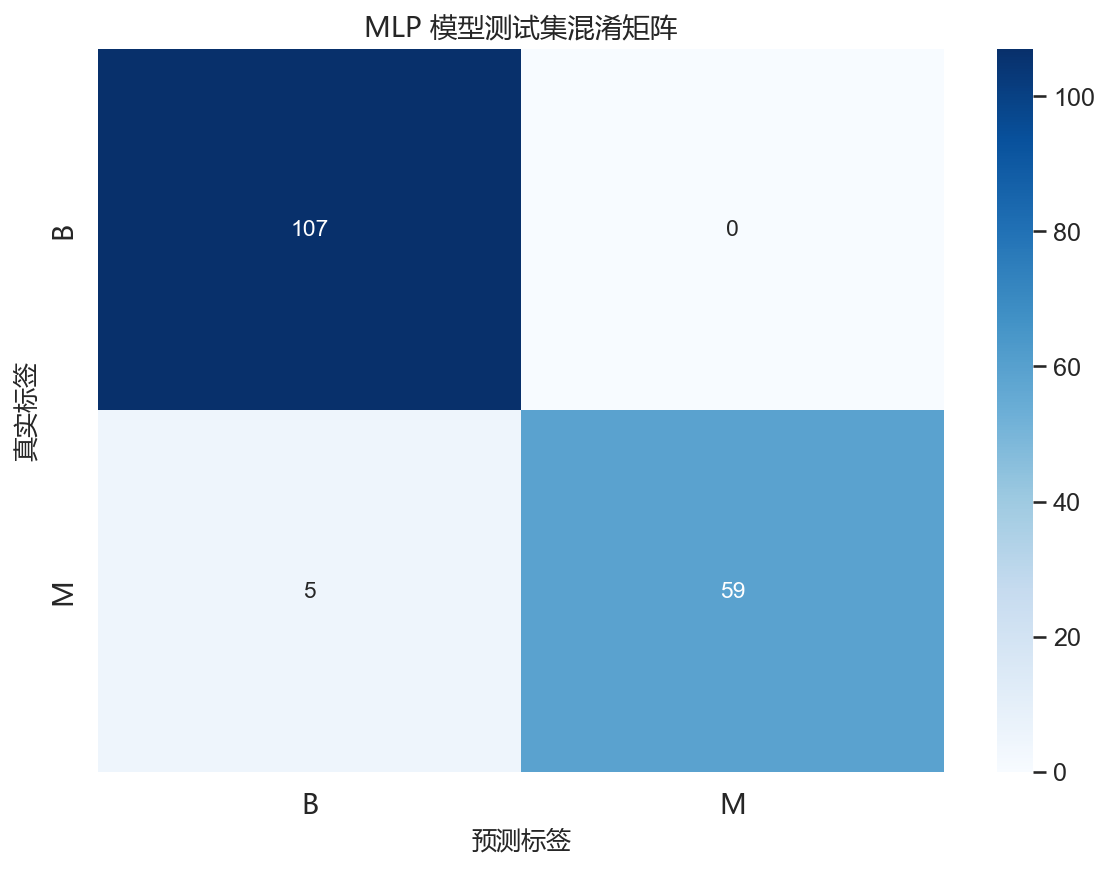

In [22]:
# 绘制混淆矩阵热力图，并保存高分辨率输出
plt.figure(figsize=(8, 6), dpi=150)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            annot_kws={'fontsize': 11})
try:
    fp
except NameError:
    import matplotlib.font_manager as fm
    from matplotlib.font_manager import FontProperties
    chinese_font = None
    for f in fm.findSystemFonts(fontpaths=None, fontext='ttf'):
        fn = f.lower()
        if any(name in fn for name in ['simhei', 'simsun', 'msyh', 'microsoftyahei', '微软雅黑', '宋体', '黑体', '楷体', '华文']):
            chinese_font = f
            break
    if chinese_font:
        fp = FontProperties(fname=chinese_font)
    else:
        fp = None
if fp is not None:
    plt.xlabel('预测标签', fontsize=12, fontproperties=fp)
    plt.ylabel('真实标签', fontsize=12, fontproperties=fp)
    plt.title('MLP 模型测试集混淆矩阵', fontsize=14, fontproperties=fp)
    plt.xticks(fontsize=11, fontproperties=fp)
    plt.yticks(fontsize=11, fontproperties=fp)
else:
    plt.xlabel('预测标签', fontsize=12)
    plt.ylabel('真实标签', fontsize=12)
    plt.title('MLP 模型测试集混淆矩阵', fontsize=14)
    plt.xticks(fontsize=11)
    plt.yticks(fontsize=11)
plt.tight_layout()
plt.savefig('mlp_confusion_matrix.png', bbox_inches='tight', dpi=150)
plt.show()


### 7. 交叉验证分析

为了进一步验证模型的泛化能力与稳定性，我们引入了 5 折交叉验证（5-Fold Cross-Validation）机制。在常规的模型评估中，如果仅依赖单次的数据划分，模型的性能指标极易受到特定数据分布的偶然性影响。交叉验证通过系统性的数据重采样，有效克服了这一局限。

在具体实施过程中，我们将训练数据集均匀地划分为 5 个互斥的子集（即“折”）。随后进行 5 轮独立的训练与验证过程：在每一轮中，选取其中 1 个子集作为验证集，剩余的 4 个子集作为训练集。模型在这 5 次迭代中会分别在不同的数据划分上进行学习，并记录每次在验证集上的表现。

最终，我们将这 5 次验证结果的平均值作为评估模型性能的核心指标。这种做法不仅充分利用了有限的数据资源，还通过多次评估平滑了单次划分可能带来的随机波动。通过交叉验证，我们能够更客观、更稳健地衡量多层感知机（MLP）在乳腺癌分类任务中的真实泛化能力，从而确保模型在实际临床应用中具备可靠的预测表现。

In [23]:
# 使用交叉验证评估模型稳定性
cv_scores = cross_val_score(mlp, X_scaled, y, cv=5, scoring='accuracy')
print('5 折交叉验证准确率:', np.round(cv_scores, 4))
print('平均准确率:', np.round(cv_scores.mean(), 4))
print('准确率标准差:', np.round(cv_scores.std(), 4))

5 折交叉验证准确率: [0.9825 0.9649 0.9649 0.9825 0.9912]
平均准确率: 0.9772
准确率标准差: 0.0105


### 8. 训练过程可视化与模型参数分析

在多层感知机（MLP）的训练过程中，实时监控模型的学习状态是确保模型健康收敛的关键环节。由于神经网络内部包含海量参数，其训练过程往往被视为一个“黑箱”，而通过可视化手段将抽象的数学优化过程具象化，能够帮助我们直观地诊断模型状态并进行针对性的调优。

#### 训练过程可视化与损失曲线监控
MLP 的训练过程通常通过损失值（Loss）曲线来进行动态监控。损失函数衡量了模型预测值与真实标签之间的差距，在基于梯度下降的优化过程中，理想状态下损失值应随着迭代轮次（Epoch）的增加而呈现平滑下降的趋势，并最终趋于平稳（即收敛）。如果损失曲线能够持续下降并顺利收敛，这通常说明当前的超参数设置（如学习率、网络规模等）与底层数据分布匹配较好，模型正在稳步学习特征与标签之间的映射关系。

#### 异常曲线诊断与参数调优策略
在实际训练中，损失曲线可能会出现各种异常形态，这为模型调优提供了直接的线索。如果损失曲线在下降过程中伴随剧烈的震荡，这通常意味着当前的学习率设置过大，导致优化过程在损失函数的极小值附近反复跨越而无法稳定；此时，适当降低学习率或切换为带有自适应学习率机制的优化器（如 Adam）往往能取得立竿见影的效果。

另一方面，如果损失曲线在下降到一定水平后便停滞不前，不再继续收敛，这可能暗示模型遇到了优化瓶颈。针对这种情况，我们需要从网络结构或数据层面进行排查：可能是隐藏层的规模过小，导致模型容量不足以拟合复杂的非线性决策边界；也可能是激活函数选择不当引发了梯度消失问题；此外，还需要检查是否存在过拟合现象（即训练集损失下降但验证集损失上升），此时可能需要引入正则化项（如 L2 正则化）或 Dropout 机制来增强模型的泛化能力。通过这种“观察曲线-诊断问题-调整参数”的闭环，我们能够不断逼近模型的最优状态。



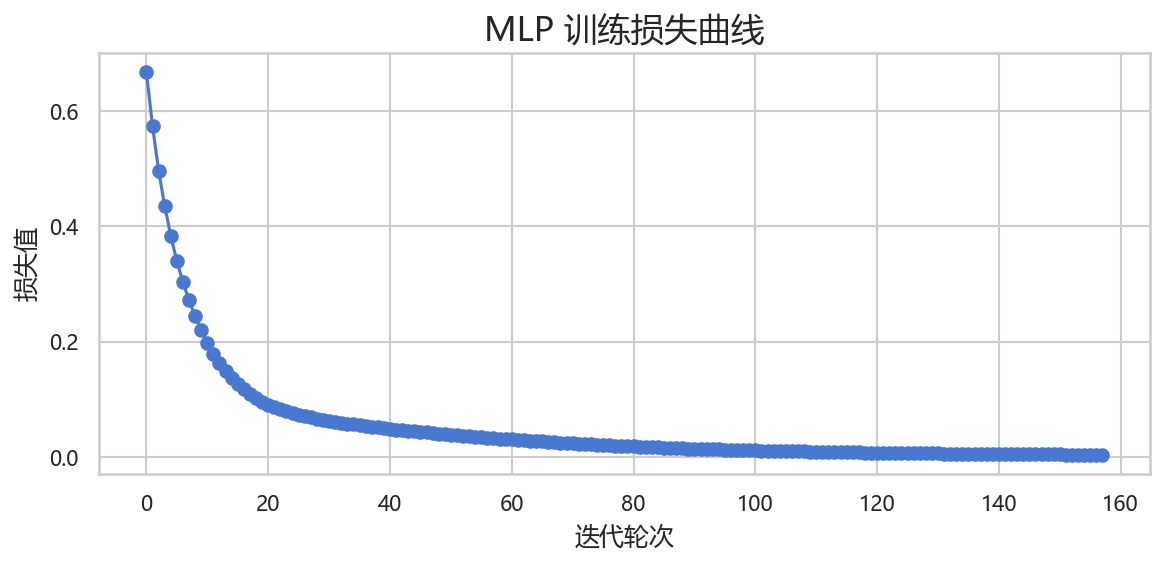

MLP 模型参数:
activation: relu
alpha: 0.0001
batch_size: auto
beta_1: 0.9
beta_2: 0.999
early_stopping: False
epsilon: 1e-08
hidden_layer_sizes: (100, 50)
learning_rate: constant
learning_rate_init: 0.001
max_fun: 15000
max_iter: 500
momentum: 0.9
n_iter_no_change: 10
nesterovs_momentum: True
power_t: 0.5
random_state: 42
shuffle: True
solver: adam
tol: 0.0001
validation_fraction: 0.1
verbose: False
warm_start: False


In [24]:
# 强化绘图，显式使用找到的中文字体并传入 FontProperties
import matplotlib as mpl
import matplotlib.font_manager as fm
from matplotlib.font_manager import FontProperties
# 在系统中查找常见中文字体
chinese_font = None
for f in fm.findSystemFonts(fontpaths=None, fontext='ttf'):
    fn = f.lower()
    if any(name in fn for name in ['simhei', 'simsun', 'msyh', 'microsoftyahei', '微软雅黑', '宋体', '黑体', '楷体', '华文']):
        chinese_font = f
        break
if chinese_font:
    fp = FontProperties(fname=chinese_font)
    font_name = fp.get_name()
    mpl.font_manager.fontManager.addfont(chinese_font)
    mpl.rcParams['font.family'] = font_name
    mpl.rcParams['font.sans-serif'] = [font_name]
else:
    fp = None
    mpl.rcParams['font.sans-serif'] = ['DejaVu Sans']
mpl.rcParams['axes.unicode_minus'] = False
mpl.rcParams['figure.dpi'] = 150
sns.set_context('notebook', font_scale=1.2)
# 绘制损失曲线
if hasattr(mlp, 'loss_curve_'):
    plt.figure(figsize=(8, 4), dpi=150)
    plt.plot(mlp.loss_curve_, marker='o', linestyle='-')
    if fp is not None:
        plt.title('MLP 训练损失曲线', fontproperties=fp, fontsize=16)
        plt.xlabel('迭代轮次', fontproperties=fp, fontsize=12)
        plt.ylabel('损失值', fontproperties=fp, fontsize=12)
        plt.xticks(fontsize=10)
        plt.yticks(fontsize=10)
    else:
        plt.title('MLP 训练损失曲线', fontsize=16)
        plt.xlabel('迭代轮次', fontsize=12)
        plt.ylabel('损失值', fontsize=12)
        plt.xticks(fontsize=10)
        plt.yticks(fontsize=10)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('mlp_loss_curve.png', bbox_inches='tight', dpi=150)
    plt.show()
else:
    print('当前 MLP 模型没有损失曲线信息。')

# 打印模型参数
print('MLP 模型参数:')
for key, value in mlp.get_params().items():
    print(f'{key}: {value}')


### 9. 超参数调优与网格搜索

多层感知机（MLP）作为一种高度灵活的深度学习模型，其最终性能在很大程度上取决于超参数的合理配置。与模型内部自动学习的权重不同，隐藏层规模（如神经元数量与层数）、正则化强度（如 `alpha` 参数）以及初始学习率等超参数，直接决定了模型的容量、收敛速度以及泛化能力。如果这些参数设置不当，模型极易陷入欠拟合或过拟合的困境。

为了科学、系统地寻找最优的超参数组合，本项目引入了 `GridSearchCV`（网格搜索交叉验证）工具。网格搜索的核心思想是“穷举法”，它会根据我们预先定义的参数网格，自动遍历所有可能的参数组合。在每一次组合下，它都会通过交叉验证来评估模型的表现，并最终筛选出在验证集上得分最高的那组超参数。这种方法虽然计算成本较高，但能够确保我们在给定的搜索空间内不遗漏任何潜在的最优解。

在实际工程落地时，必须兼顾调优效果与计算效率。由于 MLP 的训练本身较为耗时，如果参数网格过大，网格搜索的计算时间将呈指数级增长。因此，为了控制整体运行时间，我们在实践中采取了折中策略：一方面，精心挑选并缩小了候选参数的集合，仅保留对模型性能影响最核心的几个参数及其关键取值；另一方面，将交叉验证的折数设定为 3 折（3-Fold CV）。这种“小参数集 + 3 折交叉验证”的组合，既能在可接受的时间内完成搜索任务，又能有效避免单次数据划分带来的偶然性，从而在保证模型调优质量的前提下，大幅提升了算法工程师的开发效率。



In [25]:
if AUTO_RUN_FULL:
    from sklearn.model_selection import GridSearchCV
    
    # 定义超参数搜索空间
    param_grid = {
        'hidden_layer_sizes': [(50, 50), (100, 50), (100, 100)],
        'alpha': [0.0001, 0.001, 0.01],
        'learning_rate_init': [0.001, 0.01],
        'early_stopping': [True]
    }
    
    grid_search = GridSearchCV(
        estimator=MLPClassifier(
            activation='relu',
            solver='adam',
            max_iter=500,
            random_state=42
        ),
        param_grid=param_grid,
        scoring='accuracy',
        cv=3,
        n_jobs=-1,
        verbose=2
    )
    
    grid_search.fit(X_train, y_train)
    
    print('最优交叉验证得分: {:.4f}'.format(grid_search.best_score_))
    print('最优超参数组合:')
    print(grid_search.best_params_)
    
    best_mlp = grid_search.best_estimator_
    
    # 使用最优模型在测试集上评估
    best_y_pred = best_mlp.predict(X_test)
    
    print('最优模型测试集表现:')
    print('准确率: {:.4f}'.format(accuracy_score(y_test, best_y_pred)))
    print('精确率: {:.4f}'.format(precision_score(y_test, best_y_pred)))
    print('召回率: {:.4f}'.format(recall_score(y_test, best_y_pred)))
    print('F1 分数: {:.4f}'.format(f1_score(y_test, best_y_pred)))
    print('分类报告:')
    print(classification_report(y_test, best_y_pred, target_names=label_encoder.classes_))
else:
    print('跳过网格搜索；将 AUTO_RUN_FULL=True 可开启完整调参')


跳过网格搜索；将 AUTO_RUN_FULL=True 可开启完整调参


## 10. 结果解读与商业意义

- 如果网格搜索结果与初始模型差异不大，说明原始配置已经较为适合当前数据。
- 如果最优模型性能提升明显，则说明该数据集需要更强的正则化或不同的隐藏层结构。
- 在乳腺癌诊断场景中，召回率尤为重要，因为漏诊恶性肿瘤的代价远高于误诊良性肿瘤。
- 未来可根据业务需求进一步优化：对于高召回率优先，可调整阈值或使用成本敏感学习。